In [1]:
# Importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings 
warnings.filterwarnings('ignore')

In [2]:
# loading Data

df = pd.read_csv(r"customer_booking.csv", encoding='latin-1')

In [3]:
df.head()

,num_passengers,sales_channel,trip_type,purchase_lead,length_of_stay,flight_hour,flight_day,route,booking_origin,wants_extra_baggage,wants_preferred_seat,wants_in_flight_meals,flight_duration,booking_complete
0,2,Internet,RoundTrip,262,19,7,Sat,AKLDEL,New Zealand,1,0,0,5.52,0
1,1,Internet,RoundTrip,112,20,3,Sat,AKLDEL,New Zealand,0,0,0,5.52,0
2,2,Internet,RoundTrip,243,22,17,Wed,AKLDEL,India,1,1,0,5.52,0
3,1,Internet,RoundTrip,96,31,4,Sat,AKLDEL,New Zealand,0,0,1,5.52,0
4,2,Internet,RoundTrip,68,22,15,Wed,AKLDEL,India,1,0,1,5.52,0


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   num_passengers         50000 non-null  int64  
 1   sales_channel          50000 non-null  str    
 2   trip_type              50000 non-null  str    
 3   purchase_lead          50000 non-null  int64  
 4   length_of_stay         50000 non-null  int64  
 5   flight_hour            50000 non-null  int64  
 6   flight_day             50000 non-null  str    
 7   route                  50000 non-null  str    
 8   booking_origin         50000 non-null  str    
 9   wants_extra_baggage    50000 non-null  int64  
 10  wants_preferred_seat   50000 non-null  int64  
 11  wants_in_flight_meals  50000 non-null  int64  
 12  flight_duration        50000 non-null  float64
 13  booking_complete       50000 non-null  int64  
dtypes: float64(1), int64(8), str(5)
memory usage: 7.0 MB


In [5]:
df.describe(include="all")

,num_passengers,sales_channel,trip_type,purchase_lead,length_of_stay,flight_hour,flight_day,route,booking_origin,wants_extra_baggage,wants_preferred_seat,wants_in_flight_meals,flight_duration,booking_complete
count,50000.000000,50000,50000,50000.000000,50000.00000,50000.00000,50000,50000,50000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
unique,NaN,2,3,NaN,NaN,NaN,7,799,104,NaN,NaN,NaN,NaN,NaN
top,NaN,Internet,RoundTrip,NaN,NaN,NaN,Mon,AKLKUL,Australia,NaN,NaN,NaN,NaN,NaN
freq,NaN,44382,49497,NaN,NaN,NaN,8102,2680,17872,NaN,NaN,NaN,NaN,NaN
mean,1.591240,NaN,NaN,84.940480,23.04456,9.06634,NaN,NaN,NaN,0.668780,0.296960,0.427140,7.277561,0.149560
std,1.020165,NaN,NaN,90.451378,33.88767,5.41266,NaN,NaN,NaN,0.470657,0.456923,0.494668,1.496863,0.356643
min,1.000000,NaN,NaN,0.000000,0.00000,0.00000,NaN,NaN,NaN,0.000000,0.000000,0.000000,4.670000,0.000000
25%,1.000000,NaN,NaN,21.000000,5.00000,5.00000,NaN,NaN,NaN,0.000000,0.000000,0.000000,5.620000,0.000000
50%,1.000000,NaN,NaN,51.000000,17.00000,9.00000,NaN,NaN,NaN,1.000000,0.000000,0.000000,7.570000,0.000000
75%,2.000000,NaN,NaN,115.000000,28.00000,13.00000,NaN,NaN,NaN,1.000000,1.000000,1.000000,8.830000,0.000000


### OBSERVATION:
#### I get so many data like there is 'channel sales' who tells most people round 88% used internet to book tickets.
#### Trip type: most people goes for round trip
#### purchase_lead: 51days (median) before most people booked ticket. but mean is 85%   mean > median means data is right skewed.
#### 66% people wants extra baggage
#### 29% people wants there preffered seat
#### 42% people wants meals inside flight
#### Target variable: is 'booking complete" - so only 15% booked ticket and 85 not
### Key Observation : The data is highly imbalanced

In [6]:
df.shape

(50000, 14)

In [7]:
## missing value
df.isnull().sum()

num_passengers           0
sales_channel            0
trip_type                0
purchase_lead            0
length_of_stay           0
flight_hour              0
flight_day               0
route                    0
booking_origin           0
wants_extra_baggage      0
wants_preferred_seat     0
wants_in_flight_meals    0
flight_duration          0
booking_complete         0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(719)

In [9]:
dup_groups=df[df.duplicated(keep=False)]
print(len(dup_groups))

1265


In [10]:
dup_groups.drop_duplicates().shape[0]

546

In [11]:
dup_groups.groupby(
    list(df.columns.drop('booking_complete'))
)['booking_complete'].nunique().value_counts()

booking_complete
1    546
Name: count, dtype: int64

In [12]:
df = df.drop_duplicates().reset_index(drop=True)

In [13]:
df.duplicated().sum()

np.int64(0)

In [14]:
# All columns in categorical and numerical

numerical_columns = df.select_dtypes(include=[np.number]).columns.tolist()

categorical_columns = df.select_dtypes(include=["object"]).columns.tolist()

print("\n\n\nNumerical Columns"," ",numerical_columns)

print("\nCategorical Columns"," ",categorical_columns)




Numerical Columns   ['num_passengers', 'purchase_lead', 'length_of_stay', 'flight_hour', 'wants_extra_baggage', 'wants_preferred_seat', 'wants_in_flight_meals', 'flight_duration', 'booking_complete']

Categorical Columns   ['sales_channel', 'trip_type', 'flight_day', 'route', 'booking_origin']


### 1.Num passenger

In [15]:
# Num_paasenger
df['num_passengers'].value_counts()

num_passengers
1    30879
2    12669
3     2882
4     1767
5      544
6      281
7      107
8       88
9       64
Name: count, dtype: int64

In [16]:
booking_by_group = pd.crosstab(df['num_passengers'], df['booking_complete'])
booking_by_group.columns = ['Not Complete (%)', 'Complete Booking (%)']

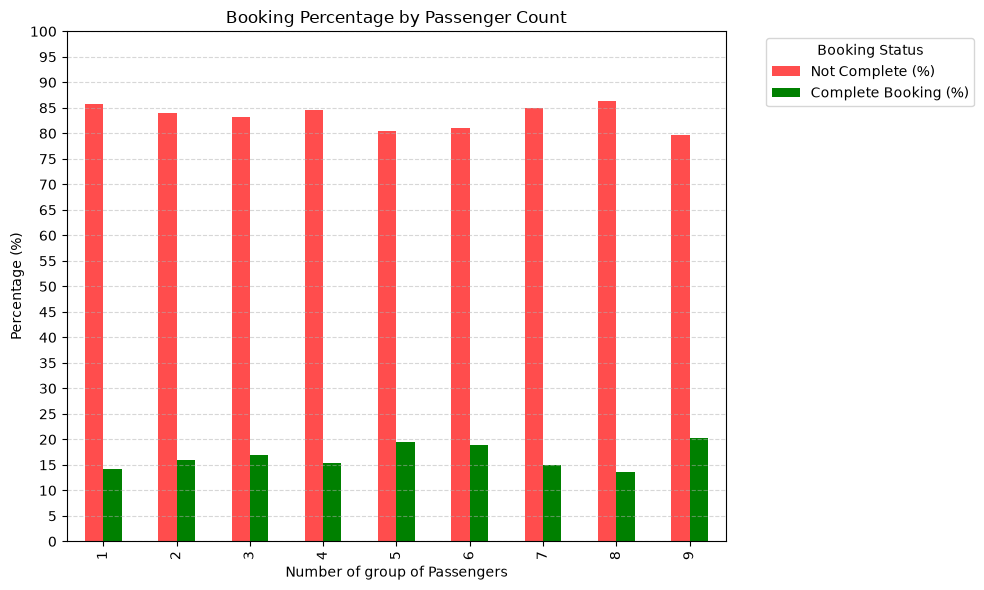

In [17]:
booking_by_group = booking_by_group.div(booking_by_group.sum(axis=1), axis=0) * 100
ax = booking_by_group.plot(kind='bar', stacked=False, figsize=(10, 6), color=['#ff4d4d', 'green'])


# 4. Labels and Legend
plt.title("Booking Percentage by Passenger Count")
plt.ylabel("Percentage (%)")
plt.xlabel("Number of group of Passengers")


plt.yticks(np.arange(0,101,5))
plt.grid(axis='y', linestyle='--',alpha=0.5)

ax.legend(title="Booking Status", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

#### OBSERVATION: 'num_passenger' column every group of customer booked there ticket in almost same ratio around only 20% in average customer booked tickets from every type of group. 

#### 2.'purchase_lead'

In [18]:
df['purchase_lead'].value_counts()

purchase_lead
1      681
2      666
6      649
7      636
5      611
      ... 
605      1
435      1
483      1
606      1
867      1
Name: count, Length: 470, dtype: int64

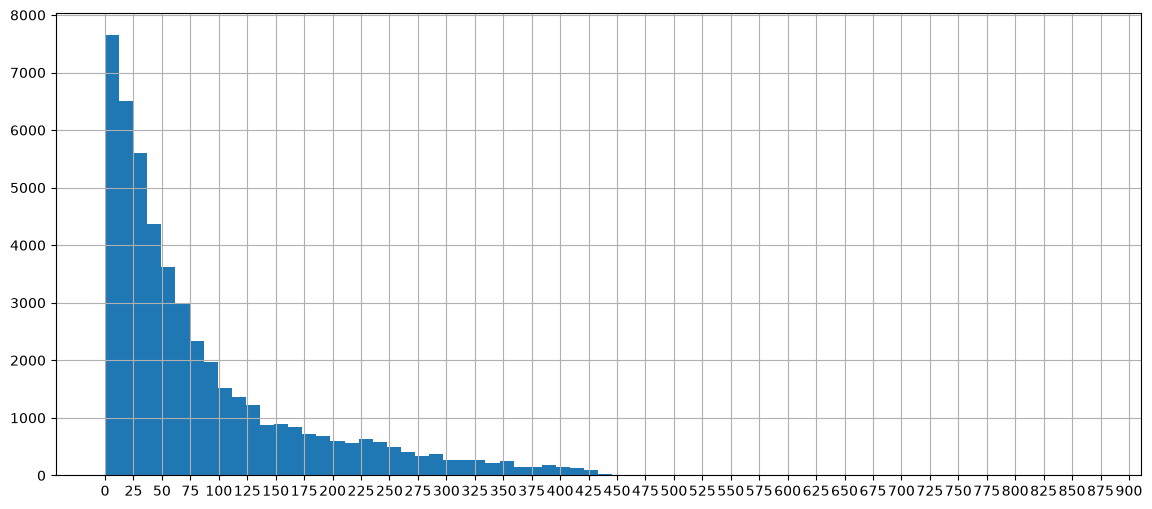

In [19]:
plt.figure(figsize=(14,6))
df['purchase_lead'].hist(bins=70)
plt.xticks(range(0,901,25))
plt.show()

#### OBSERVATION: The most data shows observations concentrated at lower lead times with a higher values and cause right skewness , the highest bars on left means the ticket is ordered before 25 > 50 > 100 > 125 > 250 and then more days before.
#### means most ticket booked before250 days 

### Extra Services add on(wants extra baggage, wants extra meal , wants preferreed seat)

In [20]:

df['extra_service_add_on'] = (
    df['wants_extra_baggage'] + df['wants_preferred_seat'] + df['wants_in_flight_meals']
)

In [21]:
df.groupby('extra_service_add_on')['booking_complete'].agg(
    ['count', 'mean']
)

,count,mean
extra_service_add_on,,
0,10344,0.106922
1,17962,0.150095
2,12362,0.160654
3,8613,0.186114


### flight day weedays and weekend 

In [22]:
df['is_weekend'] = df['flight_day'].isin(['Sat', 'Sun', 'sat', 'sun']).astype(int)

### length of stay

In [23]:
df['length_of_stay'].value_counts()

length_of_stay
6      7611
5      7151
4      5568
3      2798
17     1823
       ... 
577       1
231       1
293       1
213       1
263       1
Name: count, Length: 335, dtype: int64

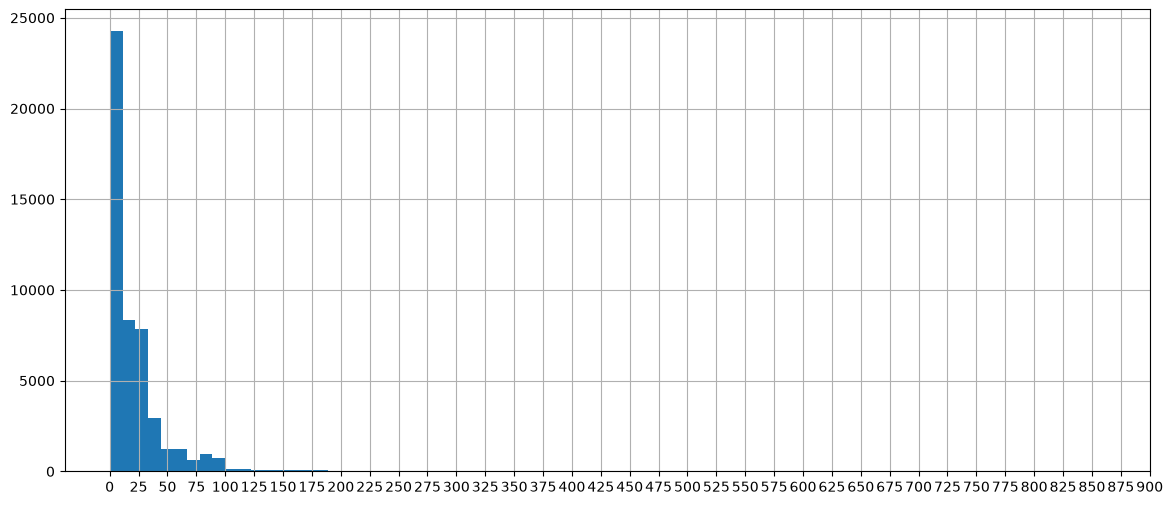

In [24]:
plt.figure(figsize=(14,6))
df['length_of_stay'].hist(bins=70)
plt.xticks(range(0,901,25))
plt.show()

In [25]:
df['stay_group'] = pd.cut(
    df['length_of_stay'],
    bins=[0, 7, 30, 60 , 90, 120 ,180,250, 365, 1000],
    labels=['0-7 days', '8-30 days','31-60 days','61-90 days',
            '91-120 days','121-180 days','181-250 days','251-365 days', '365+ days'],
    include_lowest=True
)

In [26]:
stay_analysis = (
    df.groupby('stay_group', observed=True)['booking_complete']
      .agg(['count', 'mean'])
)

stay_analysis

,count,mean
stay_group,,
0-7 days,24251,0.192528
8-30 days,14667,0.101248
31-60 days,6315,0.101979
61-90 days,2541,0.159780
91-120 days,655,0.114504
121-180 days,484,0.103306
181-250 days,177,0.192090
251-365 days,168,0.130952
365+ days,23,0.260870


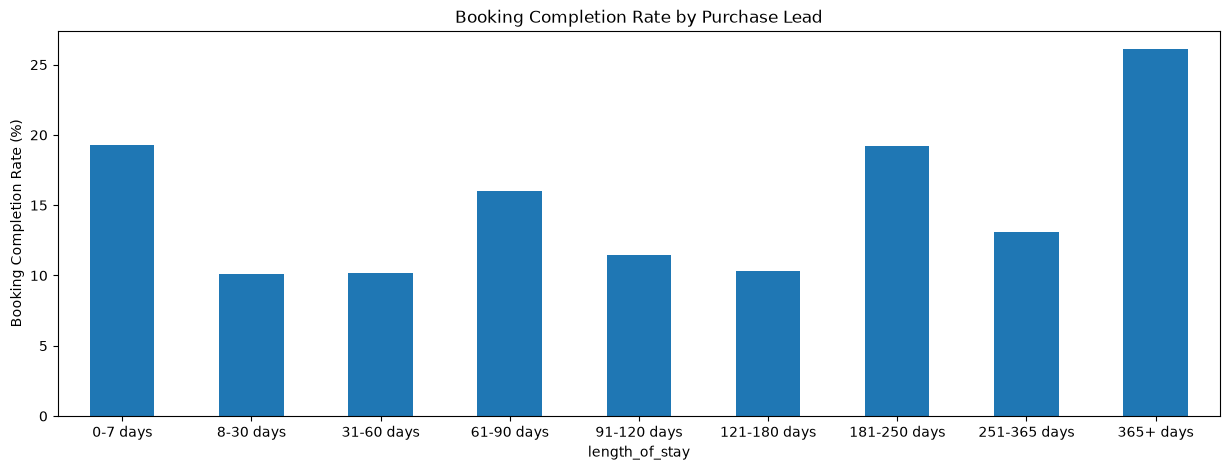

In [27]:
stay_analysis['mean'].mul(100).plot(kind='bar', figsize=(15, 5))

plt.ylabel('Booking Completion Rate (%)')
plt.xlabel('length_of_stay')
plt.title('Booking Completion Rate by Purchase Lead')
plt.xticks(rotation=0)
plt.show()

#### Obervation: Completion rate varies by booking lead-time window, with the highest rate in the 0–7 day group and lower rates across several longer lead-time groups.Booking completion varies across stay-duration groups, with short stays of 0–7 days showing a relatively high completion rate (~19.7%), followed by a sharp decline for 8–30 day stays (~10%). The relationship is non-linear rather than consistently increasing or decreasing.
#### Mostly who stays for 0-7 days have higher booking completion and then it is around 10% and we consider length of stays days only upto 120 days because rest then length of stays have very low value of booking so we are not considering that.

In [28]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 49281 entries, 0 to 49280
Data columns (total 17 columns):
 #   Column                 Non-Null Count  Dtype   
---  ------                 --------------  -----   
 0   num_passengers         49281 non-null  int64   
 1   sales_channel          49281 non-null  str     
 2   trip_type              49281 non-null  str     
 3   purchase_lead          49281 non-null  int64   
 4   length_of_stay         49281 non-null  int64   
 5   flight_hour            49281 non-null  int64   
 6   flight_day             49281 non-null  str     
 7   route                  49281 non-null  str     
 8   booking_origin         49281 non-null  str     
 9   wants_extra_baggage    49281 non-null  int64   
 10  wants_preferred_seat   49281 non-null  int64   
 11  wants_in_flight_meals  49281 non-null  int64   
 12  flight_duration        49281 non-null  float64 
 13  booking_complete       49281 non-null  int64   
 14  extra_service_add_on   49281 non-null  int64   
 

#### 4.flight_hour

In [29]:
df['flight_hour'].value_counts()

flight_hour
8     3125
12    3114
9     3097
7     3080
11    3071
10    3050
13    3046
6     3010
5     2817
4     2786
14    2783
3     2616
2     2596
15    2201
1     2071
16    1536
0     1501
23     975
17     848
22     573
18     430
21     386
19     294
20     275
Name: count, dtype: int64

In [30]:
flight_hour_analysis = (
    df.groupby('flight_hour')['booking_complete']
      .agg(['count', 'mean'])
)

flight_hour_analysis['completion_rate_%'] = (
    flight_hour_analysis['mean'] * 100
)

flight_hour_analysis

,count,mean,completion_rate_%
flight_hour,,,
0,1501,0.119920,11.992005
1,2071,0.137132,13.713182
2,2596,0.148690,14.869029
3,2616,0.146789,14.678899
4,2786,0.150395,15.039483
5,2817,0.152290,15.228967
6,3010,0.160133,16.013289
7,3080,0.137013,13.701299
8,3125,0.152960,15.296000


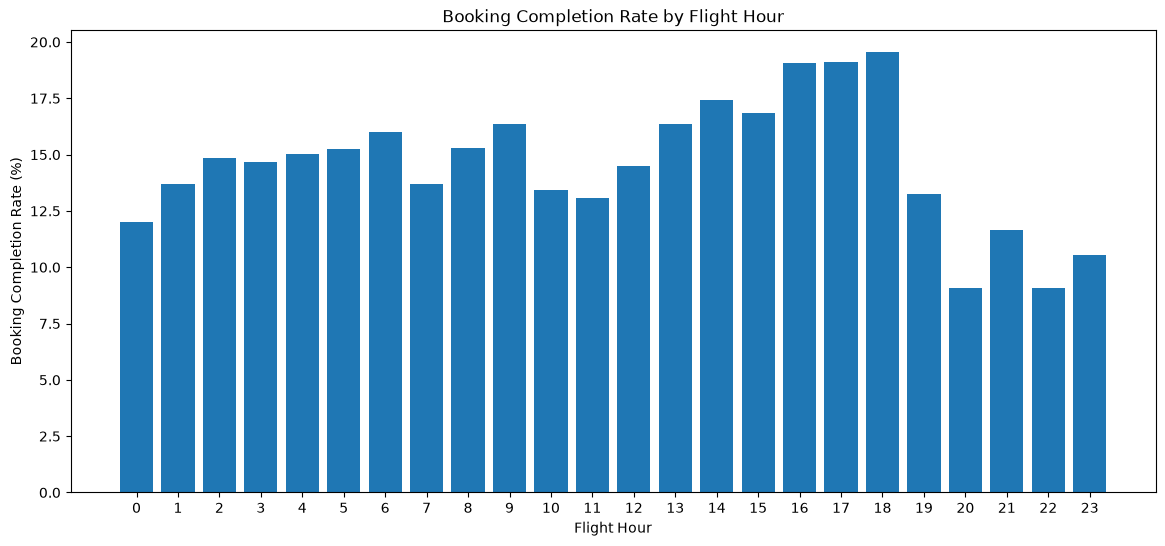

In [31]:
plt.figure(figsize=(14, 6))

plt.bar(
    flight_hour_analysis.index,
    flight_hour_analysis['completion_rate_%']
)

plt.xticks(range(24))
plt.xlabel('Flight Hour')
plt.ylabel('Booking Completion Rate (%)')
plt.title('Booking Completion Rate by Flight Hour')

plt.show()

#### Observation: Booking completion appears strongest during the afternoon/early evening, particularly around 16–18 hours, and drops noticeably during the late evening.
#### Booking completion varies significantly by flight hour. Completion rates are relatively higher during the afternoon and early evening, particularly between 14:00–18:00, where rates range from approximately 16.9% to 19.5%. After 19:00, completion drops noticeably, reaching around 9% at 20:00 and 22:00. This suggests that flight departure time is associated with booking completion behaviour.

### correlation 

<Axes: >

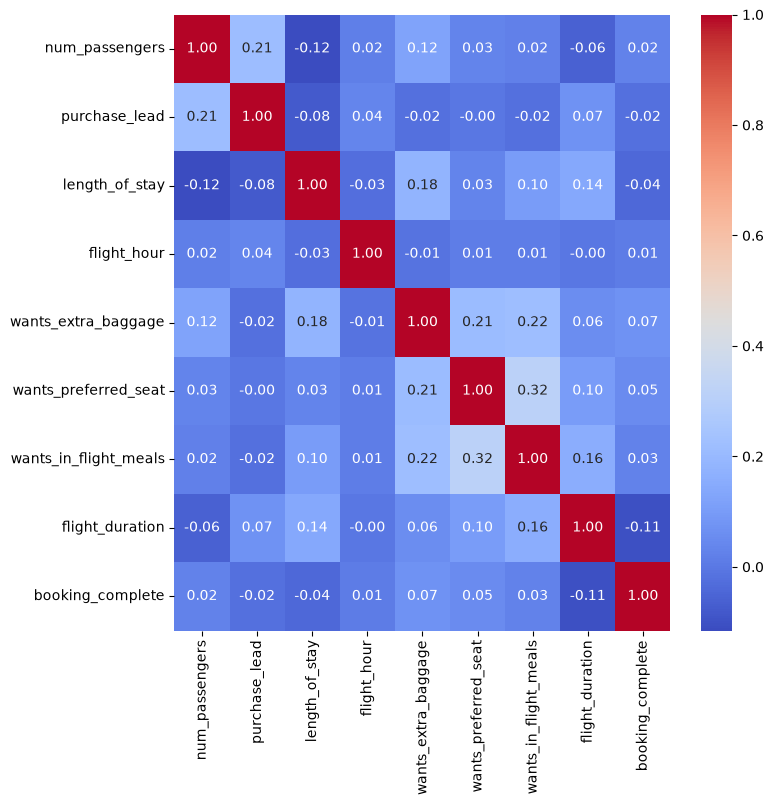

In [32]:
plt.figure(figsize=(8,8))
sns.heatmap(df[numerical_columns].corr(),annot=True, cmap='coolwarm',fmt='.2f')

### sales channel

In [33]:
df['sales_channel'].unique()

<ArrowStringArray>
['Internet', 'Mobile']
Length: 2, dtype: str

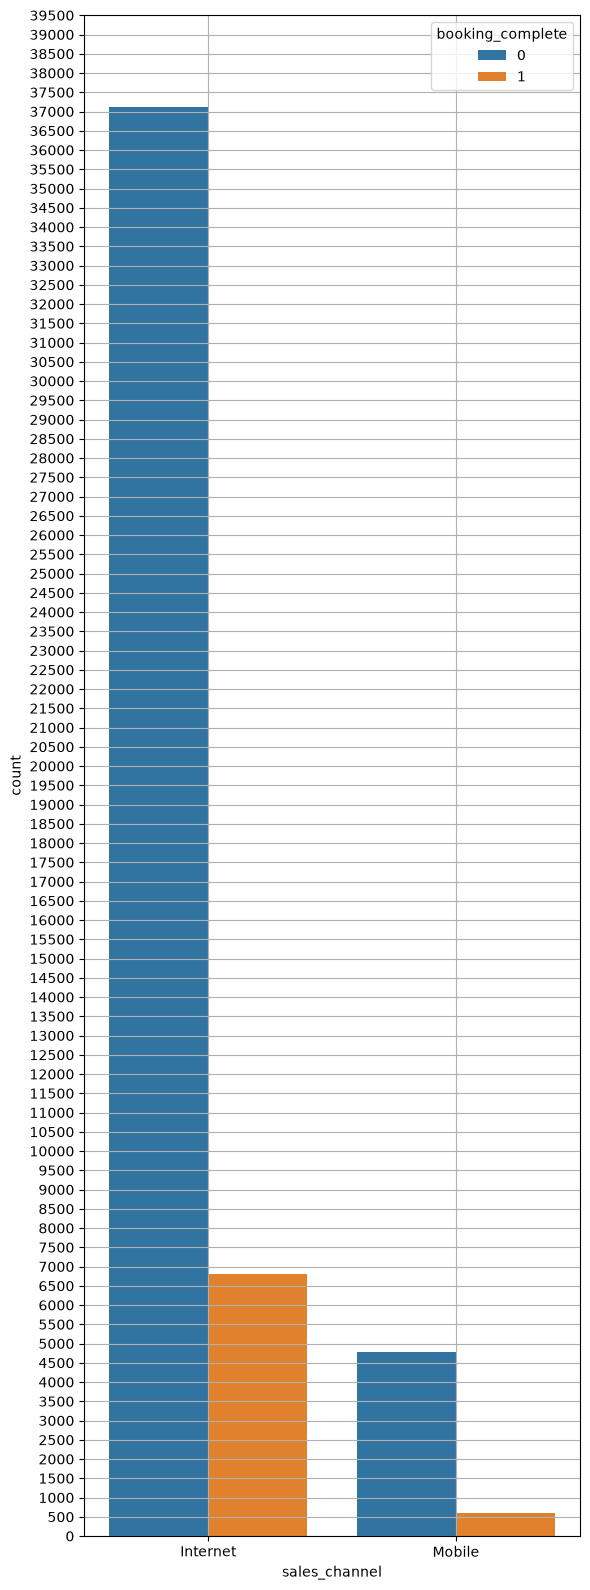

In [34]:
plt.figure(figsize=(6,16))
sns.countplot(data=df, x='sales_channel', hue='booking_complete', linewidth=1)

plt.yticks(range(0,40000,500))
plt.grid()
plt.tight_layout()
plt.show()


In [35]:
df['sales_channel'].value_counts()


sales_channel
Internet    43917
Mobile       5364
Name: count, dtype: int64

### trip type

In [36]:
df['trip_type'].value_counts()

trip_type
RoundTrip     48779
OneWay          386
CircleTrip      116
Name: count, dtype: int64

<Axes: xlabel='booking_complete', ylabel='purchase_lead'>

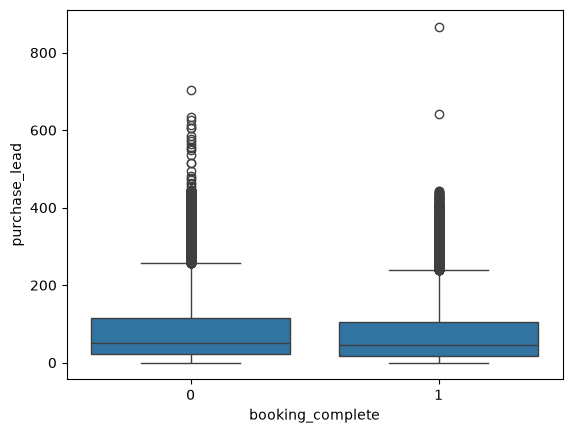

In [37]:
sns.boxplot(x='booking_complete', y='purchase_lead',data=df)

<Axes: xlabel='trip_type', ylabel='count'>

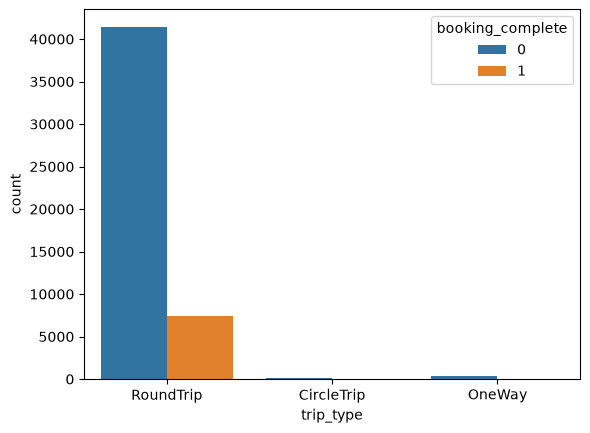

In [38]:
sns.countplot(x='trip_type', hue = 'booking_complete',data=df)

In [39]:
trip_type_analysis = (
    df.groupby('trip_type')['booking_complete']
      .agg(['count', 'mean'])
)

In [40]:
trip_type_analysis['completion_rate_%'] = (trip_type_analysis['mean'] * 100)

trip_type_analysis[['count', 'completion_rate_%']]

,count,completion_rate_%
trip_type,,
CircleTrip,116,4.310345
OneWay,386,5.181347
RoundTrip,48779,15.100761


#### observation: Booking completion varies substantially by trip type. RoundTrip customers have the highest booking completion rate at 15.10%, compared with 5.18% for OneWay and 4.31% for CircleTrip customers.
#### Key Insight: RoundTrip customers are approximately 3× more likely to complete a booking than OneWay or CircleTrip customers. This indicates that trip type is strongly associated with booking completion, with RoundTrip customers showing substantially higher purchase intent.

### selecting featured column 

In [41]:
exclude_cols = [
    'wants_extra_baggage', 'wants_preferred_seat', 
    'wants_in_flight_meals', 'flight_day','stay_group'
]

In [42]:
df_clean = df.drop(columns=[col for col in exclude_cols if col in df.columns])

In [43]:
df_clean.shape

(49281, 12)

In [44]:
df_clean.info()

<class 'pandas.DataFrame'>
RangeIndex: 49281 entries, 0 to 49280
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   num_passengers        49281 non-null  int64  
 1   sales_channel         49281 non-null  str    
 2   trip_type             49281 non-null  str    
 3   purchase_lead         49281 non-null  int64  
 4   length_of_stay        49281 non-null  int64  
 5   flight_hour           49281 non-null  int64  
 6   route                 49281 non-null  str    
 7   booking_origin        49281 non-null  str    
 8   flight_duration       49281 non-null  float64
 9   booking_complete      49281 non-null  int64  
 10  extra_service_add_on  49281 non-null  int64  
 11  is_weekend            49281 non-null  int64  
dtypes: float64(1), int64(7), str(4)
memory usage: 6.0 MB


### Machine learning pieline

In [45]:
# Segregate continuous indicators from classification target label
X = df_clean.drop(columns=['booking_complete'])
y = df_clean['booking_complete']

In [46]:
from sklearn.model_selection import train_test_split

# Lock train folds with stratify=y to secure the 85:15 scale distribution cross-validation
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

### preprocessing 

In [47]:
# 3. Target Encoding strictly on X_train
for col in ['route', 'booking_origin']:
    encoding_map = y_train.groupby(X_train[col]).mean()
    global_mean = y_train.mean()

In [48]:
X_train[f'{col}_encoded'] = X_train[col].map(encoding_map).fillna(global_mean)
X_test[f'{col}_encoded'] = X_test[col].map(encoding_map).fillna(global_mean)


In [49]:
# keeping this for pkl file
route_encoding_map = y_train.groupby(X_train['route']).mean()

In [ ]:
# Drop raw high-cardinality text columns
X_train = X_train.drop(columns=['route', 'booking_origin'])
X_test = X_test.drop(columns=['route', 'booking_origin'])

In [ ]:
# One-Hot Encoding
X_train = pd.get_dummies(X_train, columns=['sales_channel', 'trip_type'], drop_first=True)
X_test = pd.get_dummies(X_test, columns=['sales_channel', 'trip_type'], drop_first=True)
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

### scalaing standard scalar

In [ ]:
# Standard Scale continuous features to maximize gradient boundary splits
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import (f1_score, classification_report, confusion_matrix, 
                             accuracy_score, precision_score, recall_score, roc_auc_score)

def train_and_optimize_threshold_pipeline(X_train, y_train, X_test, y_test):
    estimators = {
        "Random Forest (Balanced Weights)": RandomForestClassifier(
            n_estimators=200, 
            max_depth=12, 
            class_weight='balanced', 
            random_state=42, 
            n_jobs=-1,
            min_samples_leaf=1,max_features=None,min_samples_split=15
        ),
        "XGBoost (Native Pos Scale Factor)": XGBClassifier(
            n_estimators=500, 
            learning_rate=0.05, 
            max_depth=5, 
            scale_pos_weight=5.6, 
            random_state=42, 
            eval_metric="logloss"
        ),
        "KNN": KNeighborsClassifier(
            n_neighbors=7, 
            weights='distance', 
            metric='manhattan'   

        )
        
    }
    
    summary_records = []
    
    # defining cv strategy-------------------------------------------
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    #-------------------------------------------------------------------
    
    for name, model in estimators.items():
        print(f"\nProcessing Pipeline Pipeline: {name}...")
        model.fit(X_train, y_train)

        #cross validation block----------------------------------------
        cv_recall = cross_val_score(model,X_train_scaled,y_train,cv=cv,scoring='recall')
        #-----------------------------------------------------
        
        
        # Pull baseline probabilities for the booking completed target class (1)
        y_prob = model.predict_proba(X_test)[:, 1]
        
        # Programmatically loop across 81 distinct decision bounds to maximize absolute F1 score
        threshold_steps = np.linspace(0.1, 0.9, 81)
        best_boundary = 0.5
        peak_f1_score = 0.0
        
        for boundary in threshold_steps:
            y_pred_temp = (y_prob >= boundary).astype(int)
            current_f1 = f1_score(y_test, y_pred_temp, zero_division=0)
            if current_f1 > peak_f1_score:
                peak_f1_score = current_f1
                best_boundary = boundary
                
        # Lock in final metric arrays using the optimized threshold found
        y_final_predictions = (y_prob >= best_boundary).astype(int)
        
        # Package validation scores into tracking rows
        summary_records.append({
            "Model Name": name,
            "Optimized Threshold": round(best_boundary, 2),
            "Overall Accuracy": round(accuracy_score(y_test, y_final_predictions), 4),
            "Precision Metrics": round(precision_score(y_test, y_final_predictions, zero_division=0), 4),
            "Recall Metrics": round(recall_score(y_test, y_final_predictions, zero_division=0), 4),
            "Optimized F1-Score": round(peak_f1_score, 4),
            "ROC-AUC Performance": round(roc_auc_score(y_test, y_prob), 4),
            "CV Recall mean":round(cv_recall.mean(),4),
            "CV Recall std":round(cv_recall.std(),4)
        })
        
        print(f"Optimal Boundary Discovered: {best_boundary:.2f} | F1 Max: {peak_f1_score:.4f}")
        print("Confusion Matrix Layout:\n", confusion_matrix(y_test, y_final_predictions))
        
    return pd.DataFrame(summary_records)

# Execute final pipeline analysis report
final_notebook_metrics = train_and_optimize_threshold_pipeline(X_train_scaled, y_train, X_test_scaled, y_test)
final_notebook_metrics

In [ ]:
xg_model=  XGBClassifier(
            n_estimators=500, 
            learning_rate=0.05, 
            max_depth=5, 
            scale_pos_weight=5.6, # Direct mathematical gradient factor for your 85:15 data gap
            random_state=42, 
            eval_metric="logloss"
        )
xg_model.fit(X_train_scaled,y_train)

In [ ]:
importances = pd.Series(xg_model.feature_importances_, index=X_train.columns)
importances = importances.sort_values(ascending=False)

top_features = importances.head(12)

plt.figure(figsize=(8, 6))
top_features.sort_values().plot(kind='barh')
plt.title('Top 12 Feature Importances - Random Forest')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

print(top_features)

### Saving Model

In [52]:
import joblib

In [ ]:
joblib.dump(xg_model,"BA_model.pkl")
model=joblib.load("BA_model.pkl")

In [ ]:
#save scalar
joblib.dump(scaler,"BA_scaler.pkl")

In [ ]:
#feature order
joblib.dump(X_train.columns.tolist(),"BA_feature_columns.pkl")

In [ ]:
#route encoding

joblib.dump(route_encoding_map, "route_encoding_map.pkl")

In [53]:
joblib.dump(global_mean, "global_target_mean.pkl")

['global_target_mean.pkl']

In [54]:
joblib.dump(encoding_map, "origin_encoding_map.pkl")

['origin_encoding_map.pkl']